# Experiment 3 — Author Demography × Model Performance

Models: **Qwen2.5-7B-Instruct** vs **Qwen2.5-32B-Instruct**  


---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# consistent style throughout
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

QWEN7_COLOR  = '#4C72B0'
QWEN32_COLOR = '#DD8452'
PALETTE = [QWEN7_COLOR, QWEN32_COLOR]

## Load the data

In [2]:
results = pd.read_csv('experiment3_results.csv')
rtype   = pd.read_csv('experiment3_by_reasoning_type.csv')

print('experiment3_results.csv :', results.shape)
print('experiment3_by_reasoning_type.csv:', rtype.shape)

experiment3_results.csv : (45, 17)
experiment3_by_reasoning_type.csv: (271, 11)


In [3]:
# quick peek
results.head(8)

,dimension,group_value,author_nationality,Qwen_7B_mean_brier,Qwen_7B_std_brier,Qwen_7B_mean_accuracy,Qwen_7B_std_accuracy,Qwen_7B_n,Qwen_32B_mean_brier,Qwen_32B_std_brier,Qwen_32B_mean_accuracy,Qwen_32B_std_accuracy,Qwen_32B_n,n_questions,author_profession,source_genre,date_bin
0,author_nationality,American,American,0.1886,0.0799,0.2225,0.4159,418,0.1775,0.0753,0.2560,0.4364,418,418,NaN,NaN,NaN
1,author_nationality,British Isles,British Isles,0.2095,0.0871,0.1826,0.3864,219,0.1967,0.0827,0.2374,0.4255,219,219,NaN,NaN,NaN
2,author_nationality,Canadian,Canadian,0.2187,0.0431,0.0000,0.0000,11,0.1841,0.0761,0.1818,0.3857,11,11,NaN,NaN,NaN
3,author_nationality,Chinese,Chinese,0.1212,0.0559,0.3333,0.4714,3,0.1805,0.0771,0.0000,0.0000,3,3,NaN,NaN,NaN
4,author_nationality,Chinese-American,Chinese-American,0.2149,NaN,0.0000,NaN,1,0.2075,NaN,0.0000,NaN,1,1,NaN,NaN,NaN
5,author_nationality,Indian,Indian,0.1382,0.0366,0.5000,0.5000,4,0.1650,0.0277,0.5000,0.5000,4,4,NaN,NaN,NaN
6,author_nationality,Italian,Italian,0.2016,NaN,0.0000,NaN,1,0.1874,NaN,0.0000,NaN,1,1,NaN,NaN,NaN
7,author_nationality,Japanese,Japanese,0.2248,0.0089,0.0000,0.0000,3,0.2156,0.0381,0.0000,0.0000,3,3,NaN,NaN,NaN


In [4]:
# what dimensions do we have?
print('Dimensions:', results['dimension'].unique())
print('Rows per dimension:')
results['dimension'].value_counts()

Dimensions: <StringArray>
['author_nationality', 'author_profession', 'source_genre', 'date_bin']
Length: 4, dtype: str
Rows per dimension:


dimension
author_profession     15
source_genre          15
author_nationality    12
date_bin               3
Name: count, dtype: int64

In [5]:
# helper — pull out a clean slice for a given dimension
def get_dim(df, dim, min_questions=5):
    sub = df[df['dimension'] == dim].copy()
    sub['n_questions'] = pd.to_numeric(sub['n_questions'], errors='coerce')
    sub['Qwen_7B_mean_accuracy']  = pd.to_numeric(sub['Qwen_7B_mean_accuracy'],  errors='coerce')
    sub['Qwen_32B_mean_accuracy'] = pd.to_numeric(sub['Qwen_32B_mean_accuracy'], errors='coerce')
    sub['Qwen_7B_mean_brier']     = pd.to_numeric(sub['Qwen_7B_mean_brier'],     errors='coerce')
    sub['Qwen_32B_mean_brier']    = pd.to_numeric(sub['Qwen_32B_mean_brier'],     errors='coerce')
    sub = sub[sub['n_questions'] >= min_questions].copy()
    sub = sub.sort_values('n_questions', ascending=False)
    return sub

nat   = get_dim(results, 'author_nationality', min_questions=4)
prof  = get_dim(results, 'author_profession',  min_questions=8)
genre = get_dim(results, 'source_genre',       min_questions=8)
dbin  = get_dim(results, 'date_bin',           min_questions=1)

print(f'Nationality groups: {len(nat)}, Profession groups: {len(prof)}, Genre groups: {len(genre)}')

Nationality groups: 8, Profession groups: 15, Genre groups: 15


---
## Overall model performance

Before splitting by demographics, let's just confirm what the baseline numbers are.

In [6]:
# load the raw question-level data so we can compute totals ourselves
import json, os

BOOKSAMPLE = os.path.join('..', '..', 'booksample')
EVAL_FILES = {
    'Qwen-7B':  os.path.join(BOOKSAMPLE, 'eval_results_full_Qwen_Qwen2.5-7B-Instruct_20260316_174038.json'),
    'Qwen-32B': os.path.join(BOOKSAMPLE, 'eval_results_full_Qwen_Qwen2.5-32B-Instruct_20260322_101723.json'),
}

def load_eval(path):
    with open(path) as f:
        d = json.load(f)
    return d['metadata'], d['per_question_results']

questions = [json.loads(l) for l in open(os.path.join(BOOKSAMPLE, 'chronologic_en_0.1.jsonl'))]

def brier(model_probs, answer_probs):
    n = min(len(model_probs), len(answer_probs))
    return sum((model_probs[i] - answer_probs[i])**2 for i in range(n)) / n

rows = []
for model_name, path in EVAL_FILES.items():
    _, results_raw = load_eval(path)
    for i, (q, r) in enumerate(zip(questions, results_raw)):
        mp = r.get('model_probs') or []
        ap = q.get('answer_probabilities') or []
        rows.append({
            'model': model_name,
            'idx': i,
            'author_nationality': q.get('author_nationality',''),
            'author_profession':  q.get('author_profession',''),
            'source_genre':       q.get('source_genre',''),
            'source_date':        q.get('source_date'),
            'reasoning_type':     q.get('reasoning_type',''),
            'correct':            int(r['correct']),
            'brier':              brier(mp, ap) if mp and ap else np.nan,
        })

df = pd.DataFrame(rows)
print(df.shape)
df.head()

(1418, 9)


,model,idx,author_nationality,author_profession,source_genre,source_date,reasoning_type,correct,brier
0,Qwen-7B,0,British,classical scholar,critical treatise,1907,phrase_cloze,0,0.120122
1,Qwen-7B,1,Indian,poet and social reformer,travelogue,1891,constrained_generation,1,0.091075
2,Qwen-7B,2,American,writer,work of history and social description,1910,phrase_cloze,0,0.167875
3,Qwen-7B,3,British,classical scholar,critical treatise,1907,phrase_cloze,0,0.212031
4,Qwen-7B,4,British,biographer and novelist,memoir,1917,phrase_cloze,0,0.170986


In [7]:
overall = df.groupby('model').agg(
    accuracy=('correct','mean'),
    brier=('brier','mean'),
    n=('correct','count')
).reset_index()
overall['accuracy_pct'] = overall['accuracy'] * 100
overall

,model,accuracy,brier,n,accuracy_pct
0,Qwen-32B,0.239774,0.185673,709,23.977433
1,Qwen-7B,0.201693,0.198035,709,20.169252


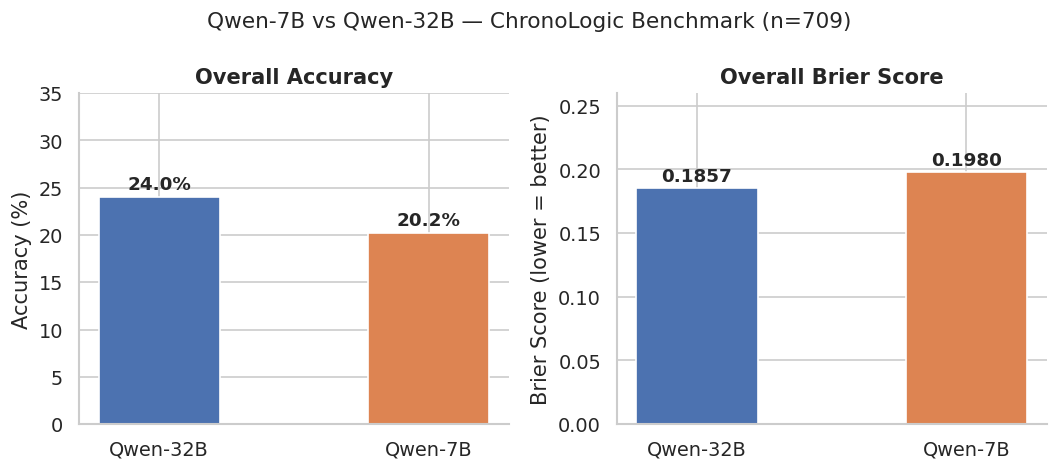

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# accuracy
bars = axes[0].bar(overall['model'], overall['accuracy_pct'], color=PALETTE, width=0.45, edgecolor='white')
for bar, val in zip(bars, overall['accuracy_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Overall Accuracy', fontweight='bold')
axes[0].set_ylim(0, 35)

# brier score
bars2 = axes[1].bar(overall['model'], overall['brier'], color=PALETTE, width=0.45, edgecolor='white')
for bar, val in zip(bars2, overall['brier']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Brier Score (lower = better)')
axes[1].set_title('Overall Brier Score', fontweight='bold')
axes[1].set_ylim(0, 0.26)

# fig.suptitle('Qwen-7B vs Qwen-32B — ChronoLogic Benchmark (n=709)', fontsize=13)
plt.tight_layout()
plt.savefig('experiment3_plots/00_overall_performance.png', bbox_inches='tight')
plt.show()

Qwen-32B is better, but not dramatically so — accuracy goes from ~20% to ~24%, Brier score improves by about 0.012. This is a hard benchmark either way.

---
## 1. Author Nationality

In [9]:
# normalise nationality the same way the analysis script does
NAT_MAP = {
    'American':'American', 'United States':'American',
    'British':'British Isles', 'English':'British Isles',
    'Scottish':'British Isles', 'Irish':'British Isles', 'Welsh':'British Isles',
    'Canadian':'Canadian', 'Australian':'Australian',
    'South African':'South African',
    'German':'German', 'French':'French', 'Italian':'Italian', 'Russian':'Russian',
}

df['nationality_norm'] = df['author_nationality'].map(lambda x: NAT_MAP.get(str(x).strip(), str(x).strip()) if x else 'Unknown')
df.loc[df['nationality_norm'].isin(['','nan','unknown']), 'nationality_norm'] = 'Unknown'

nat_agg = df.groupby(['nationality_norm','model']).agg(
    accuracy=('correct','mean'),
    brier=('brier','mean'),
    n=('correct','count')
).reset_index()

# only show groups with at least 4 questions
counts = nat_agg.groupby('nationality_norm')['n'].max()
keep = counts[counts >= 4].index
nat_agg = nat_agg[nat_agg['nationality_norm'].isin(keep)]
nat_agg['accuracy_pct'] = nat_agg['accuracy'] * 100

nat_order = (nat_agg.groupby('nationality_norm')['n']
             .max().sort_values(ascending=False).index.tolist())
nat_agg['nationality_norm'] = pd.Categorical(nat_agg['nationality_norm'], categories=nat_order, ordered=True)
nat_agg = nat_agg.sort_values('nationality_norm')
nat_agg

,nationality_norm,model,accuracy,brier,n,accuracy_pct
0,American,Qwen-32B,0.255981,0.177521,418,25.598086
1,American,Qwen-7B,0.222488,0.188583,418,22.248804
2,British Isles,Qwen-32B,0.237443,0.196741,219,23.744292
3,British Isles,Qwen-7B,0.182648,0.209457,219,18.264840
20,Unknown,Qwen-32B,0.100000,0.218917,30,10.000000
21,Unknown,Qwen-7B,0.133333,0.239631,30,13.333333
4,Canadian,Qwen-32B,0.181818,0.184086,11,18.181818
5,Canadian,Qwen-7B,0.000000,0.218702,11,0.000000
16,South African,Qwen-32B,0.250000,0.218027,8,25.000000
17,South African,Qwen-7B,0.125000,0.244417,8,12.500000


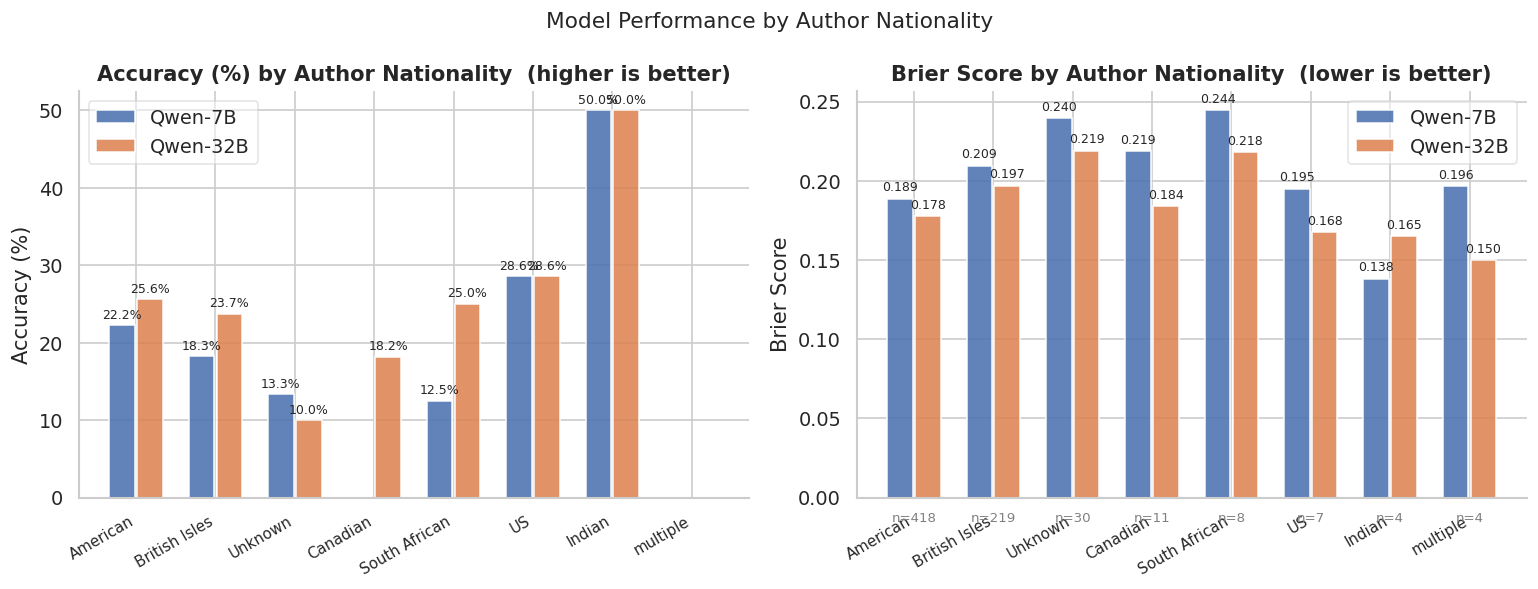

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, label, better in [
    (axes[0], 'accuracy_pct', 'Accuracy (%)', 'higher'),
    (axes[1], 'brier',        'Brier Score',  'lower'),
]:
    groups = nat_order
    x = np.arange(len(groups))
    w = 0.35

    for i, (model, color) in enumerate([('Qwen-7B', QWEN7_COLOR), ('Qwen-32B', QWEN32_COLOR)]):
        sub = nat_agg[nat_agg['model'] == model].set_index('nationality_norm')
        vals = [sub.loc[g, metric] if g in sub.index else 0 for g in groups]
        ns   = [sub.loc[g, 'n']    if g in sub.index else 0 for g in groups]
        bars = ax.bar(x + (i - 0.5) * w, vals, w * 0.92, label=model,
                      color=color, alpha=0.88, edgecolor='white')
        for bar, v, n in zip(bars, vals, ns):
            if v > 0:
                txt = f'{v:.1f}%' if metric == 'accuracy_pct' else f'{v:.3f}'
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + (0.5 if metric == 'accuracy_pct' else 0.003),
                        txt, ha='center', va='bottom', fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels(groups, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(label)
    ax.set_title(f'{label} by Author Nationality  ({better} is better)', fontweight='bold')
    ax.legend(framealpha=0.5)

# annotate sample sizes below x-axis for the right chart
for g, xpos in zip(nat_order, range(len(nat_order))):
    n = nat_agg[nat_agg['nationality_norm'] == g]['n'].max()
    axes[1].text(xpos, -0.035, f'n={n}', ha='center', va='top',
                 fontsize=8, color='gray', transform=axes[1].get_xaxis_transform())

plt.suptitle('Model Performance by Author Nationality', fontsize=13)
plt.tight_layout()
plt.savefig('experiment3_plots/01_nationality.png', bbox_inches='tight')
plt.show()

In [11]:
# is the difference between American and British statistically notable?
for model in ['Qwen-7B', 'Qwen-32B']:
    sub = df[df['model'] == model]
    am  = sub[sub['nationality_norm'] == 'American']['correct']
    bi  = sub[sub['nationality_norm'] == 'British Isles']['correct']
    diff = am.mean() - bi.mean()
    print(f"{model}  →  American {am.mean()*100:.1f}%  |  British Isles {bi.mean()*100:.1f}%  |  gap: +{diff*100:.1f}pp  (n_am={len(am)}, n_bi={len(bi)})")

Qwen-7B  →  American 22.2%  |  British Isles 18.3%  |  gap: +4.0pp  (n_am=418, n_bi=219)
Qwen-32B  →  American 25.6%  |  British Isles 23.7%  |  gap: +1.9pp  (n_am=418, n_bi=219)


Both models show a consistent ~4 pp advantage for American authors over British Isles authors. The gap is nearly identical across model sizes, suggesting this is a data/corpus bias, not something the larger model "corrects" by knowing more.

---
## 2. Author Profession

In [12]:
df['profession_clean'] = df['author_profession'].fillna('Unknown').str.strip()
df.loc[df['profession_clean'] == '', 'profession_clean'] = 'Unknown'

# truncate very long profession strings for readability
df['profession_clean'] = df['profession_clean'].apply(lambda x: x[:30] if len(x) > 30 else x)

prof_agg = df.groupby(['profession_clean','model']).agg(
    accuracy=('correct','mean'),
    brier=('brier','mean'),
    n=('correct','count')
).reset_index()

# keep professions with >= 8 questions in either model
big = prof_agg.groupby('profession_clean')['n'].max()
keep_prof = big[big >= 8].index
prof_agg = prof_agg[prof_agg['profession_clean'].isin(keep_prof)].copy()
prof_agg['accuracy_pct'] = prof_agg['accuracy'] * 100

# sort by average accuracy across both models
avg_acc = prof_agg.groupby('profession_clean')['accuracy_pct'].mean().sort_values(ascending=False)
prof_order = avg_acc.index.tolist()
prof_agg['profession_clean'] = pd.Categorical(prof_agg['profession_clean'], categories=prof_order, ordered=True)
prof_agg = prof_agg.sort_values('profession_clean')
prof_agg.head(10)

,profession_clean,model,accuracy,brier,n,accuracy_pct
71,mathematics teacher,Qwen-7B,0.500000,0.139026,14,50.000000
70,mathematics teacher,Qwen-32B,0.642857,0.122055,14,64.285714
69,mathematician,Qwen-7B,0.454545,0.152531,22,45.454545
68,mathematician,Qwen-32B,0.590909,0.125535,22,59.090909
106,professor of electrical engine,Qwen-32B,0.500000,0.142616,8,50.000000
107,professor of electrical engine,Qwen-7B,0.500000,0.133485,8,50.000000
12,author,Qwen-32B,0.352941,0.159620,17,35.294118
13,author,Qwen-7B,0.294118,0.181681,17,29.411765
123,unknown,Qwen-7B,0.333333,0.140335,9,33.333333
122,unknown,Qwen-32B,0.222222,0.146428,9,22.222222


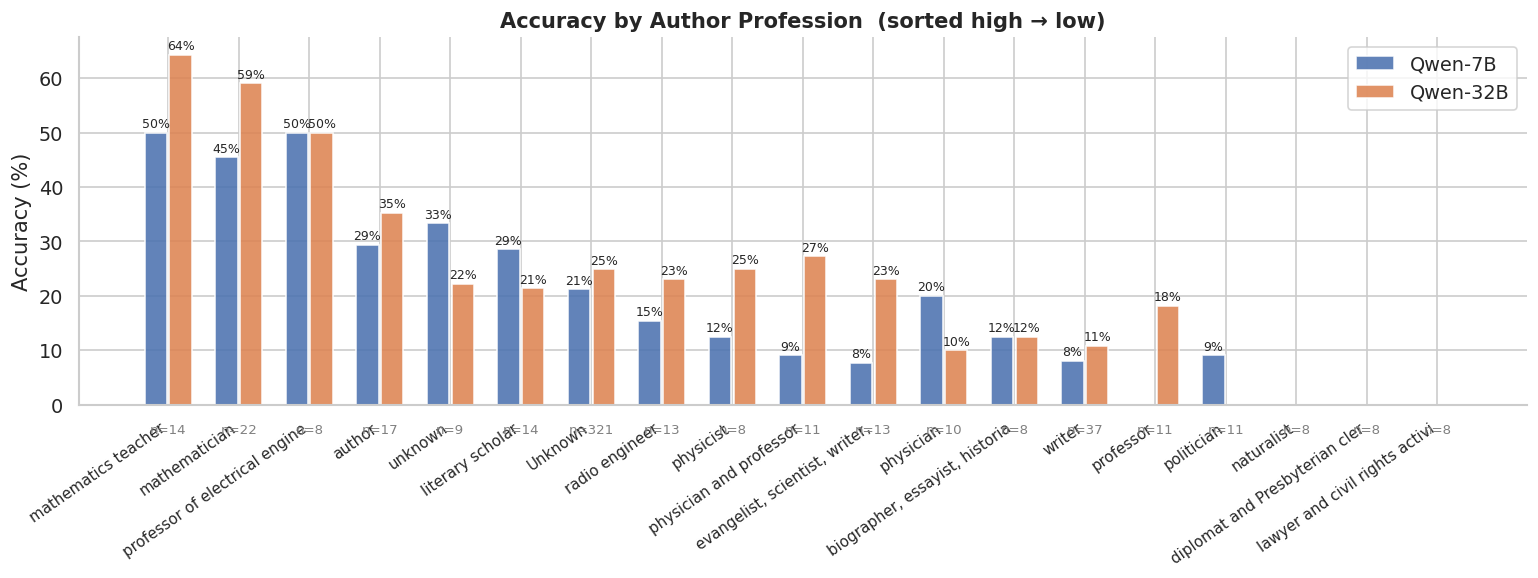

In [13]:
fig, ax = plt.subplots(figsize=(13, 5))

x = np.arange(len(prof_order))
w = 0.35

for i, (model, color) in enumerate([('Qwen-7B', QWEN7_COLOR), ('Qwen-32B', QWEN32_COLOR)]):
    sub = prof_agg[prof_agg['model'] == model].set_index('profession_clean')
    vals = [sub.loc[g, 'accuracy_pct'] if g in sub.index else 0 for g in prof_order]
    ns   = [sub.loc[g, 'n'] if g in sub.index else 0 for g in prof_order]
    bars = ax.bar(x + (i - 0.5) * w, vals, w * 0.9, label=model,
                  color=color, alpha=0.88, edgecolor='white')
    for bar, v, n in zip(bars, vals, ns):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                    f'{v:.0f}%', ha='center', va='bottom', fontsize=7.5)

# sample size annotation
for g, xpos in zip(prof_order, range(len(prof_order))):
    n = prof_agg[prof_agg['profession_clean'] == g]['n'].max()
    ax.text(xpos, -0.05, f'n={n}', ha='center', va='top',
            fontsize=8, color='gray', transform=ax.get_xaxis_transform())

ax.set_xticks(x)
ax.set_xticklabels(prof_order, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy by Author Profession  (sorted high → low)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('experiment3_plots/02_profession_accuracy.png', bbox_inches='tight')
plt.show()

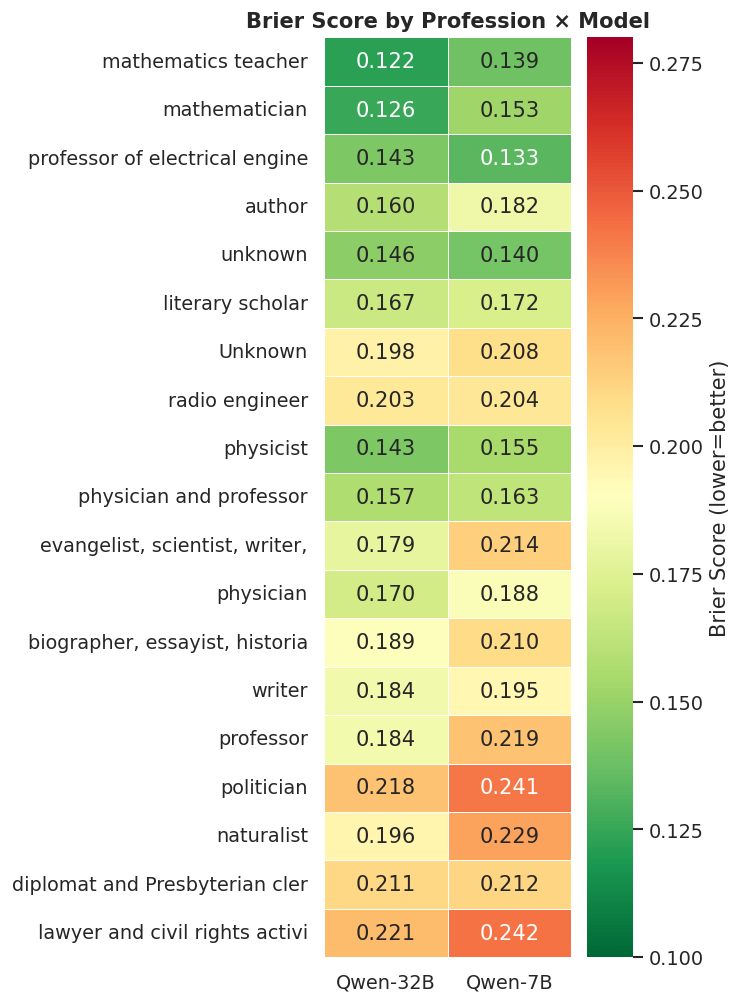

In [14]:
# Brier score heatmap-style view — useful to see calibration differences
pivot_brier = prof_agg.pivot_table(index='profession_clean', columns='model', values='brier')
pivot_brier = pivot_brier.loc[prof_order]  # keep sort order

fig, ax = plt.subplots(figsize=(6, max(4, len(prof_order) * 0.45)))
sns.heatmap(pivot_brier, annot=True, fmt='.3f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Brier Score (lower=better)'},
            vmin=0.10, vmax=0.28)
ax.set_title('Brier Score by Profession × Model', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('experiment3_plots/02b_profession_brier_heatmap.png', bbox_inches='tight')
plt.show()

STEM authors (mathematicians, math teachers) are by far the easiest category — accuracy 45-64%. Literary writers score the lowest (8-11%), even though they're a big chunk of the dataset.

---
## 3. Source Genre

In [15]:
df['genre_clean'] = df['source_genre'].fillna('Unknown').str.strip()
df.loc[df['genre_clean'] == '', 'genre_clean'] = 'Unknown'

genre_agg = df.groupby(['genre_clean','model']).agg(
    accuracy=('correct','mean'),
    brier=('brier','mean'),
    n=('correct','count')
).reset_index()

counts_g = genre_agg.groupby('genre_clean')['n'].max()
keep_g = counts_g[counts_g >= 8].index
genre_agg = genre_agg[genre_agg['genre_clean'].isin(keep_g)].copy()
genre_agg['accuracy_pct'] = genre_agg['accuracy'] * 100

genre_order = (genre_agg.groupby('genre_clean')['accuracy_pct']
               .mean().sort_values(ascending=False).index.tolist())

print('Genres kept:', genre_order)

Genres kept: ['practical manual', 'examination manual', 'textbook', 'historical novel', 'encyclopedia', 'ethnology', 'book of poems', 'memoir', 'novel', 'hobbyist textbook', 'technical handbook', 'novel with ethnographic elements', 'science and religion discourse', 'story for children', 'cultural history', 'history', 'journal', 'book of essays', 'debate', 'educational guide', 'public address', 'serial']


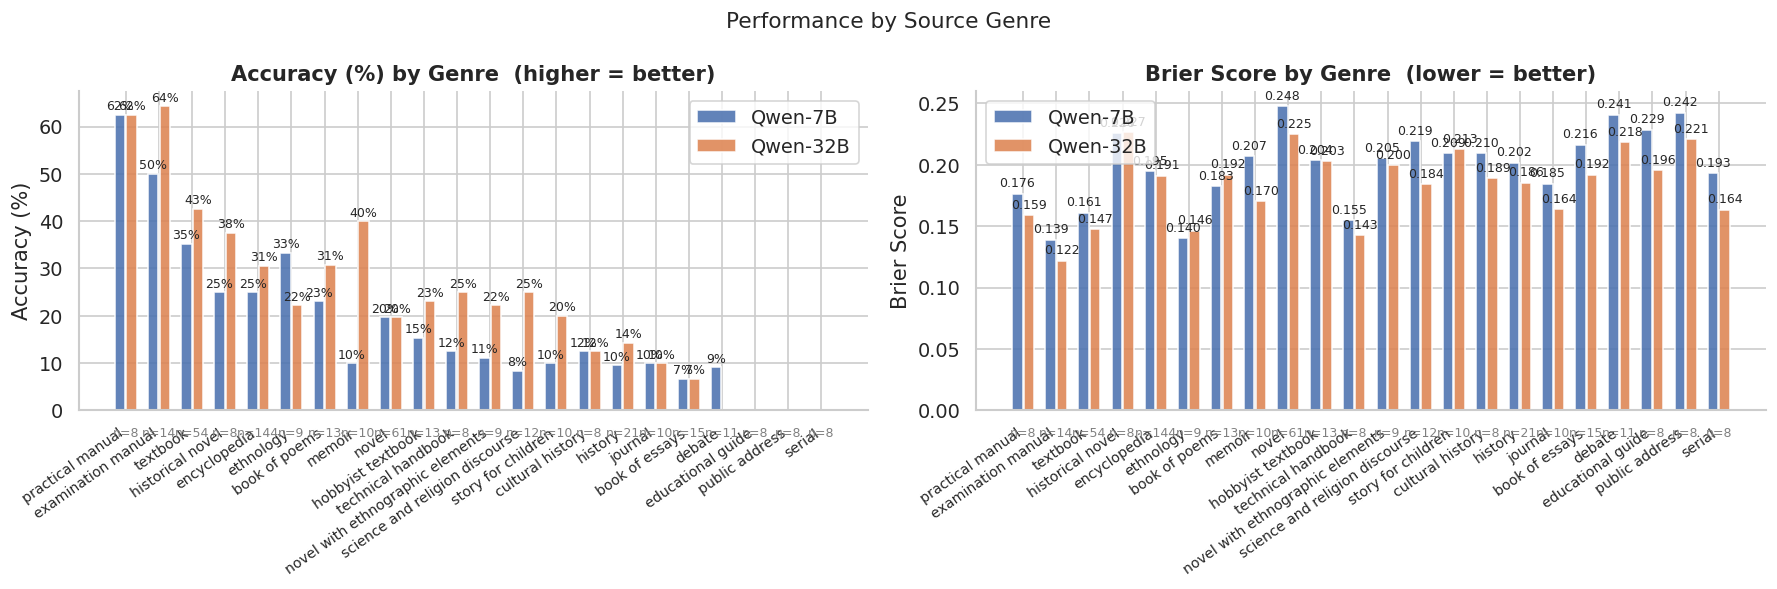

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, metric, ylabel, better in [
    (axes[0], 'accuracy_pct', 'Accuracy (%)', 'higher'),
    (axes[1], 'brier', 'Brier Score', 'lower'),
]:
    x = np.arange(len(genre_order))
    w = 0.35
    for i, (model, color) in enumerate([('Qwen-7B', QWEN7_COLOR), ('Qwen-32B', QWEN32_COLOR)]):
        sub = genre_agg[genre_agg['model'] == model].set_index('genre_clean')
        vals = [sub.loc[g, metric] if g in sub.index else 0 for g in genre_order]
        bars = ax.bar(x + (i - 0.5) * w, vals, w * 0.9, label=model,
                      color=color, alpha=0.88, edgecolor='white')
        for bar, v in zip(bars, vals):
            if v > 0:
                txt = f'{v:.0f}%' if metric == 'accuracy_pct' else f'{v:.3f}'
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.4 if metric=='accuracy_pct' else 0.003),
                        txt, ha='center', va='bottom', fontsize=7.5)
    ax.set_xticks(x)
    ax.set_xticklabels(genre_order, rotation=35, ha='right', fontsize=8.5)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} by Genre  ({better} = better)', fontweight='bold')
    ax.legend()

    for g, xpos in zip(genre_order, range(len(genre_order))):
        n = genre_agg[genre_agg['genre_clean'] == g]['n'].max()
        ax.text(xpos, -0.05, f'n={n}', ha='center', va='top',
                fontsize=7.5, color='gray', transform=ax.get_xaxis_transform())

plt.suptitle('Performance by Source Genre', fontsize=13)
plt.tight_layout()
plt.savefig('experiment3_plots/03_genre.png', bbox_inches='tight')
plt.show()

In [17]:
# The novel vs textbook gap is stark — let's quantify it
for model in ['Qwen-7B', 'Qwen-32B']:
    sub = df[df['model'] == model]
    novel = sub[sub['genre_clean'] == 'novel']['correct']
    text  = sub[sub['genre_clean'] == 'textbook']['correct']
    enc   = sub[sub['genre_clean'] == 'encyclopedia']['correct']
    print(f"{model}:  novel={novel.mean()*100:.1f}%  textbook={text.mean()*100:.1f}%  encyclopedia={enc.mean()*100:.1f}%")

Qwen-7B:  novel=19.7%  textbook=35.2%  encyclopedia=25.0%
Qwen-32B:  novel=19.7%  textbook=42.6%  encyclopedia=30.6%


Textbooks and encyclopedias are ~2× easier than novels. Fiction is not just harder to understand — it requires knowing the specific text, characters, and exact phrasing, which is almost impossible without strong memorisation.

---
## 4. Publication Date

In [18]:
# scatter plot of accuracy over time — one dot per year
year_agg = df.dropna(subset=['source_date']).copy()
year_agg['source_date'] = pd.to_numeric(year_agg['source_date'], errors='coerce')
year_agg = year_agg.dropna(subset=['source_date'])
year_agg = year_agg[(year_agg['source_date'] >= 1870) & (year_agg['source_date'] <= 1930)]

year_acc = year_agg.groupby(['source_date','model']).agg(
    accuracy=('correct','mean'),
    n=('correct','count')
).reset_index()

year_acc.head()

,source_date,model,accuracy,n
0,1873,Qwen-32B,0.200000,10
1,1873,Qwen-7B,0.100000,10
2,1875,Qwen-32B,0.220000,50
3,1875,Qwen-7B,0.260000,50
4,1876,Qwen-32B,0.166667,6


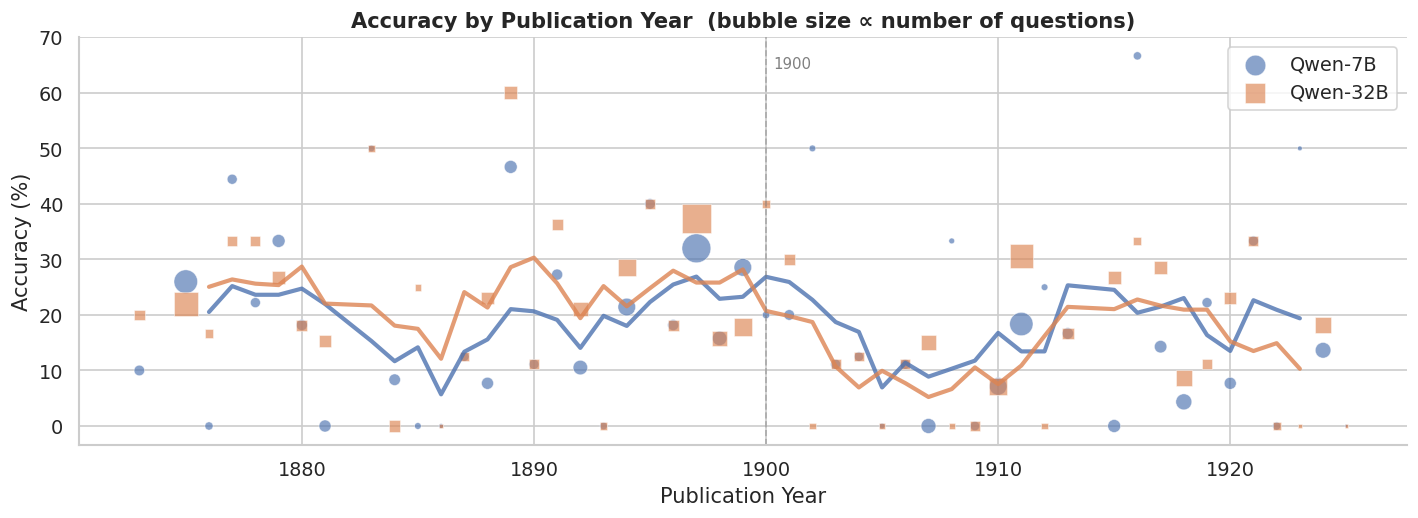

In [19]:
fig, ax = plt.subplots(figsize=(12, 4.5))

for model, color, marker in [('Qwen-7B', QWEN7_COLOR, 'o'), ('Qwen-32B', QWEN32_COLOR, 's')]:
    sub = year_acc[year_acc['model'] == model]
    # bubble size by n questions
    ax.scatter(sub['source_date'], sub['accuracy'] * 100,
               s=sub['n'] * 4, color=color, alpha=0.65, label=model,
               marker=marker, edgecolors='white', linewidths=0.4)
    # rolling trend
    sub_s = sub.sort_values('source_date')
    if len(sub_s) > 4:
        trend = sub_s.set_index('source_date')['accuracy'].rolling(5, center=True).mean() * 100
        ax.plot(trend.index, trend.values, color=color, linewidth=2.5, alpha=0.8)

ax.axvline(1900, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.text(1900.3, ax.get_ylim()[1] * 0.92, '1900', color='gray', fontsize=9)
ax.set_xlabel('Publication Year')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy by Publication Year  (bubble size ∝ number of questions)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('experiment3_plots/04_year_scatter.png', bbox_inches='tight')
plt.show()

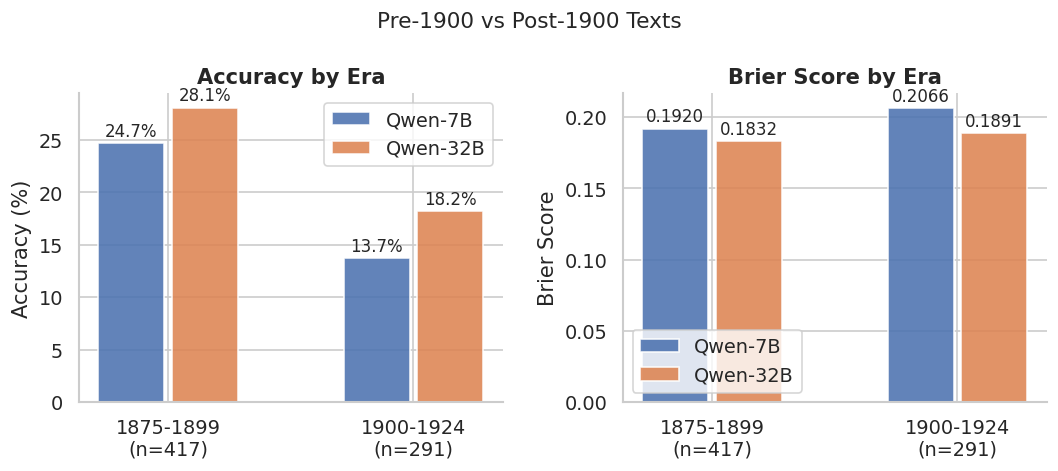

In [20]:
# bar chart: the two date bins
df['date_bin'] = df['source_date'].apply(lambda x: '1875-1899' if pd.notnull(x) and int(x) <= 1899
                                          else ('1900-1924' if pd.notnull(x) and int(x) <= 1924 else 'Other'))

bin_agg = df[df['date_bin'].isin(['1875-1899','1900-1924'])].groupby(['date_bin','model']).agg(
    accuracy=('correct','mean'),
    brier=('brier','mean'),
    n=('correct','count')
).reset_index()
bin_agg['accuracy_pct'] = bin_agg['accuracy'] * 100

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, metric, ylabel in [
    (axes[0], 'accuracy_pct', 'Accuracy (%)'),
    (axes[1], 'brier',        'Brier Score'),
]:
    bins = ['1875-1899', '1900-1924']
    x = np.arange(len(bins))
    w = 0.3
    for i, (model, color) in enumerate([('Qwen-7B', QWEN7_COLOR), ('Qwen-32B', QWEN32_COLOR)]):
        sub = bin_agg[bin_agg['model'] == model].set_index('date_bin')
        vals = [sub.loc[b, metric] if b in sub.index else 0 for b in bins]
        ns   = [sub.loc[b, 'n']    if b in sub.index else 0 for b in bins]
        bars = ax.bar(x + (i - 0.5) * w, vals, w * 0.9, label=model,
                      color=color, alpha=0.88, edgecolor='white')
        for bar, v, n in zip(bars, vals, ns):
            if v > 0:
                txt = f'{v:.1f}%' if metric == 'accuracy_pct' else f'{v:.4f}'
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.3 if metric=='accuracy_pct' else 0.002),
                        txt, ha='center', va='bottom', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{b}\n(n={bin_agg[bin_agg["date_bin"]==b]["n"].max()})' for b in bins])
    ax.set_ylabel(ylabel)
    ax.legend()

axes[0].set_title('Accuracy by Era', fontweight='bold')
axes[1].set_title('Brier Score by Era', fontweight='bold')
plt.suptitle('Pre-1900 vs Post-1900 Texts', fontsize=13)
plt.tight_layout()
plt.savefig('experiment3_plots/04_date_bins.png', bbox_inches='tight')
plt.show()

Pre-1900 texts score ~10pp higher than post-1900. This is counterintuitive — you might expect older texts to be harder. But older canonical texts (Dickens, Twain, encyclopedia editions) may just appear more frequently in pretraining corpora.

---
## 5. Reasoning Type

In [21]:
rtype_agg = df.groupby(['reasoning_type','model']).agg(
    accuracy=('correct','mean'),
    brier=('brier','mean'),
    n=('correct','count')
).reset_index()
rtype_agg['accuracy_pct'] = rtype_agg['accuracy'] * 100

rtype_order = (rtype_agg.groupby('reasoning_type')['accuracy_pct']
               .mean().sort_values(ascending=False).index.tolist())

rtype_agg

,reasoning_type,model,accuracy,brier,n,accuracy_pct
0,abstention,Qwen-32B,0.090909,0.278982,55,9.090909
1,abstention,Qwen-7B,0.109091,0.296886,55,10.909091
2,character_modeling,Qwen-32B,0.219780,0.214866,91,21.978022
3,character_modeling,Qwen-7B,0.186813,0.231287,91,18.681319
4,constrained_generation,Qwen-32B,0.263158,0.191066,95,26.315789
5,constrained_generation,Qwen-7B,0.221053,0.192385,95,22.105263
6,inference,Qwen-32B,0.472973,0.143625,74,47.297297
7,inference,Qwen-7B,0.418919,0.157444,74,41.891892
8,knowledge,Qwen-32B,0.447059,0.158664,85,44.705882
9,knowledge,Qwen-7B,0.352941,0.160505,85,35.294118


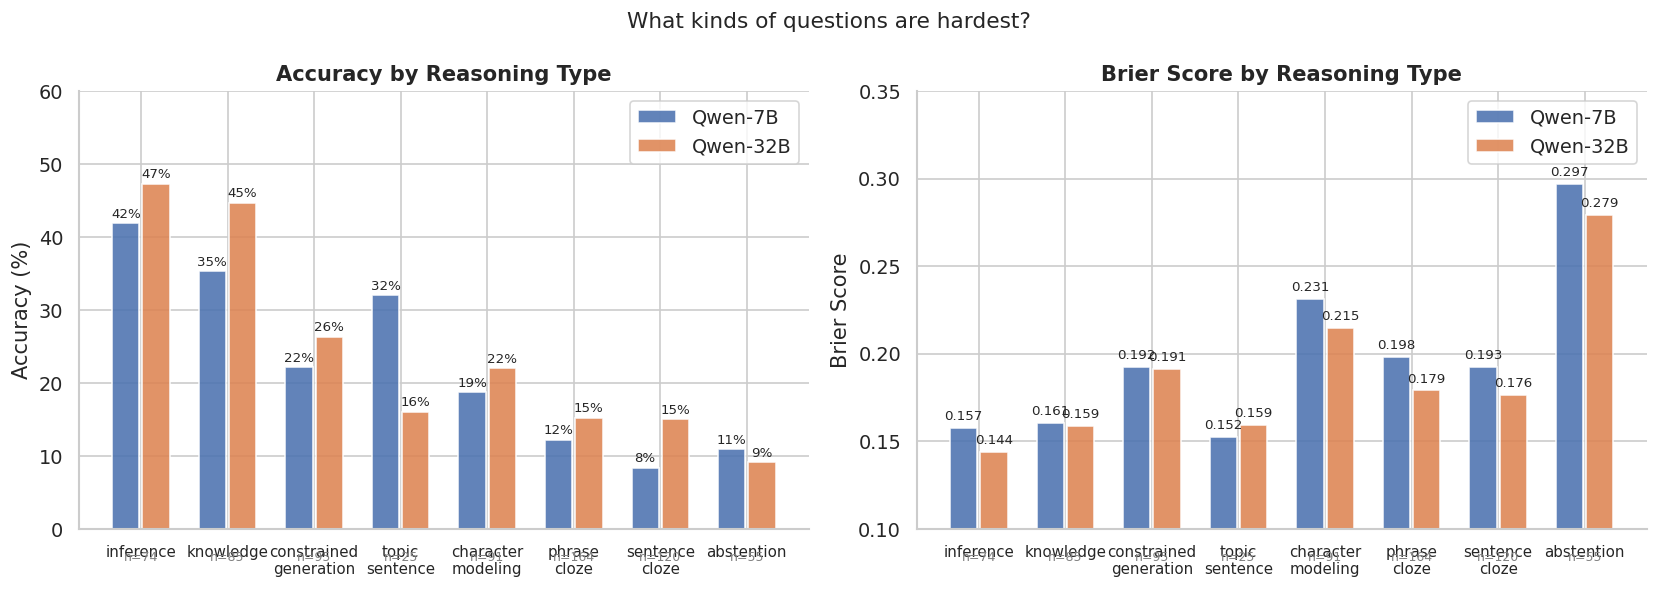

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, ylabel, ylim in [
    (axes[0], 'accuracy_pct', 'Accuracy (%)', (0, 60)),
    (axes[1], 'brier',        'Brier Score',  (0.10, 0.35)),
]:
    x = np.arange(len(rtype_order))
    w = 0.35
    for i, (model, color) in enumerate([('Qwen-7B', QWEN7_COLOR), ('Qwen-32B', QWEN32_COLOR)]):
        sub = rtype_agg[rtype_agg['model'] == model].set_index('reasoning_type')
        vals = [sub.loc[g, metric] if g in sub.index else 0 for g in rtype_order]
        bars = ax.bar(x + (i - 0.5) * w, vals, w * 0.9, label=model,
                      color=color, alpha=0.88, edgecolor='white')
        for bar, v in zip(bars, vals):
            if v > 0:
                txt = f'{v:.0f}%' if metric == 'accuracy_pct' else f'{v:.3f}'
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.4 if metric=='accuracy_pct' else 0.003),
                        txt, ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels([r.replace('_', '\n') for r in rtype_order], fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_ylim(ylim)
    ax.legend()

    for g, xpos in zip(rtype_order, range(len(rtype_order))):
        n = rtype_agg[rtype_agg['reasoning_type'] == g]['n'].max()
        ax.text(xpos, -0.05, f'n={n}', ha='center', va='top',
                fontsize=7.5, color='gray', transform=ax.get_xaxis_transform())

axes[0].set_title('Accuracy by Reasoning Type', fontweight='bold')
axes[1].set_title('Brier Score by Reasoning Type', fontweight='bold')
plt.suptitle('What kinds of questions are hardest?', fontsize=13)
plt.tight_layout()
plt.savefig('experiment3_plots/05_reasoning_type.png', bbox_inches='tight')
plt.show()

---
## 6. Cross-analysis: Nationality × Reasoning Type

The most interesting question: does the nationality gap exist across all reasoning types, or is it driven by one specific type?

In [23]:
# load from the cross csv
cross_raw = pd.read_csv('experiment3_by_reasoning_type.csv')
cross_nat = cross_raw[cross_raw['dimension'] == 'author_nationality'].copy()
cross_nat = cross_nat[cross_nat['author_nationality'].isin(['American','British Isles'])]

for c in ['Qwen_7B_mean_accuracy','Qwen_32B_mean_accuracy','Qwen_7B_n','Qwen_32B_n']:
    cross_nat[c] = pd.to_numeric(cross_nat[c], errors='coerce')

cross_nat.head(10)

,dimension,author_nationality,reasoning_type,Qwen_7B_mean_brier,Qwen_7B_mean_accuracy,Qwen_7B_n,Qwen_32B_mean_brier,Qwen_32B_mean_accuracy,Qwen_32B_n,source_genre,date_bin
0,author_nationality,American,abstention,0.2509,0.2083,24,0.2442,0.1250,24,NaN,NaN
1,author_nationality,American,character_modeling,0.2274,0.1071,28,0.2158,0.1786,28,NaN,NaN
2,author_nationality,American,constrained_generation,0.1948,0.2692,52,0.1894,0.2885,52,NaN,NaN
3,author_nationality,American,inference,0.1487,0.4808,52,0.1354,0.5192,52,NaN,NaN
4,author_nationality,American,knowledge,0.1625,0.3594,64,0.1656,0.4219,64,NaN,NaN
5,author_nationality,American,phrase_cloze,0.2031,0.0800,100,0.1801,0.1400,100,NaN,NaN
6,author_nationality,American,sentence_cloze,0.1939,0.0933,75,0.1776,0.1600,75,NaN,NaN
7,author_nationality,American,topic_sentence,0.1448,0.3478,23,0.1512,0.1739,23,NaN,NaN
8,author_nationality,British Isles,abstention,0.3151,0.0500,20,0.3012,0.0500,20,NaN,NaN
9,author_nationality,British Isles,character_modeling,0.2314,0.2364,55,0.2139,0.2364,55,NaN,NaN


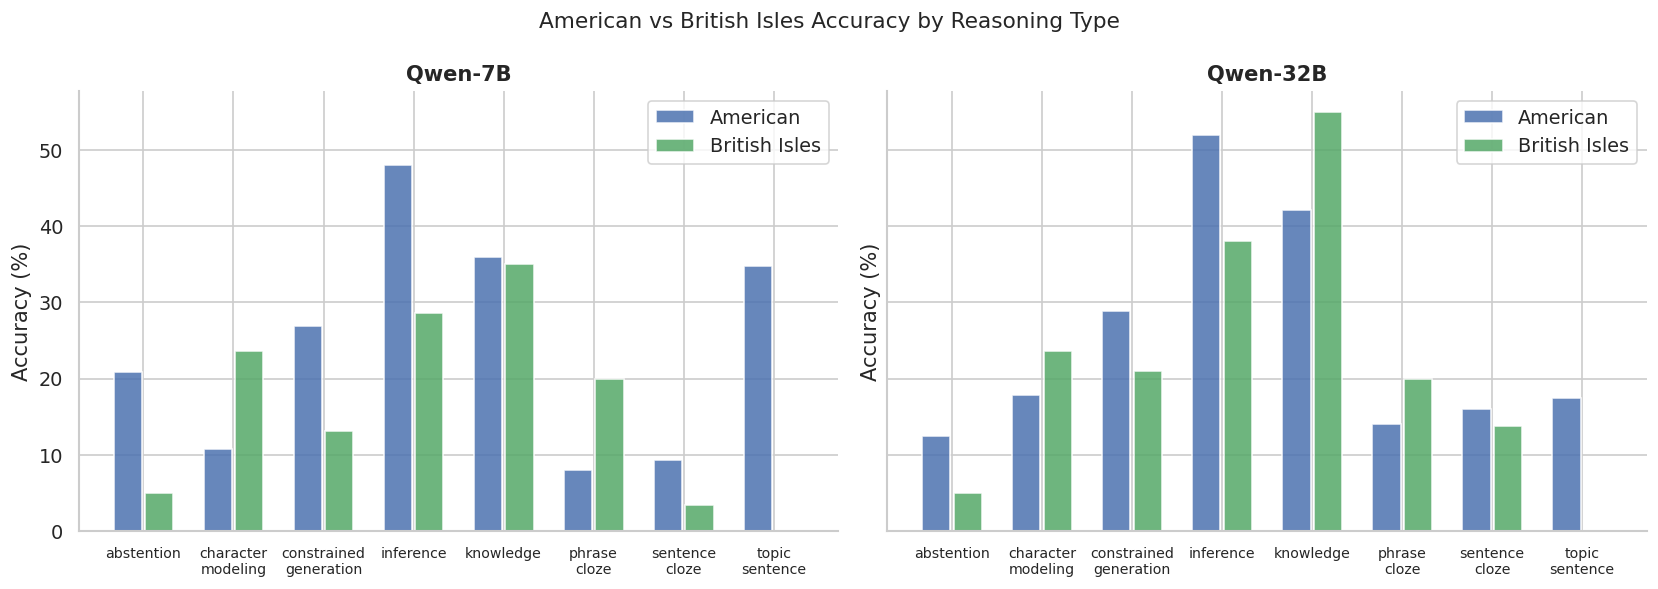

In [24]:
# pivot so we can plot American vs British side by side per reasoning type
pivot_7b  = cross_nat.pivot_table(index='reasoning_type', columns='author_nationality', values='Qwen_7B_mean_accuracy')
pivot_32b = cross_nat.pivot_table(index='reasoning_type', columns='author_nationality', values='Qwen_32B_mean_accuracy')

rtype_list = sorted(pivot_7b.index.tolist())

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, pivot, title in [
    (axes[0], pivot_7b,  'Qwen-7B'),
    (axes[1], pivot_32b, 'Qwen-32B'),
]:
    x = np.arange(len(rtype_list))
    w = 0.35
    nat_colors = {'American': '#4C72B0', 'British Isles': '#55A868'}
    for i, nat in enumerate(['American','British Isles']):
        vals = [pivot.loc[r, nat] * 100 if r in pivot.index and nat in pivot.columns and pd.notnull(pivot.loc[r, nat]) else 0
                for r in rtype_list]
        bars = ax.bar(x + (i - 0.5) * w, vals, w * 0.9,
                      label=nat, color=nat_colors[nat], alpha=0.85, edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels([r.replace('_','\n') for r in rtype_list], fontsize=8.5)
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.suptitle('American vs British Isles Accuracy by Reasoning Type', fontsize=13)
plt.tight_layout()
plt.savefig('experiment3_plots/06_nat_x_reasoning.png', bbox_inches='tight')
plt.show()

In [25]:
# the gap per reasoning type — where is the American advantage largest?
gap = (pivot_7b['American'] - pivot_7b['British Isles']) * 100
gap_32b = (pivot_32b['American'] - pivot_32b['British Isles']) * 100
gap_df = pd.DataFrame({'Qwen-7B gap (pp)': gap, 'Qwen-32B gap (pp)': gap_32b}).dropna()
gap_df = gap_df.sort_values('Qwen-7B gap (pp)', ascending=False)
gap_df.round(1)

,Qwen-7B gap (pp),Qwen-32B gap (pp)
reasoning_type,,
topic_sentence,34.8,17.4
inference,19.5,13.8
abstention,15.8,7.5
constrained_generation,13.8,7.8
sentence_cloze,5.9,2.2
knowledge,0.9,-12.8
phrase_cloze,-12.0,-6.0
character_modeling,-12.9,-5.8


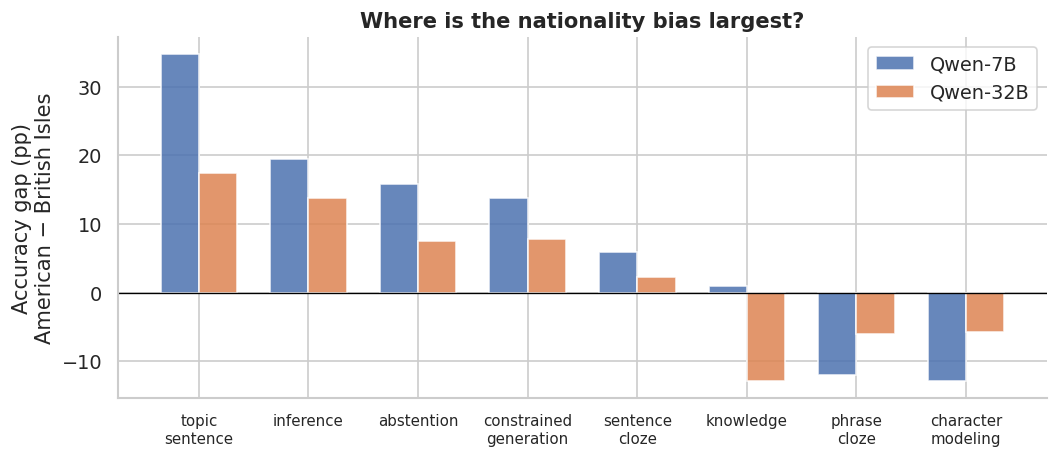

In [26]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(gap_df))
w = 0.35
ax.bar(x - w/2, gap_df['Qwen-7B gap (pp)'],  w, label='Qwen-7B',  color=QWEN7_COLOR,  alpha=0.85, edgecolor='white')
ax.bar(x + w/2, gap_df['Qwen-32B gap (pp)'], w, label='Qwen-32B', color=QWEN32_COLOR, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([r.replace('_','\n') for r in gap_df.index], fontsize=9)
ax.set_ylabel('Accuracy gap (pp)\nAmerican − British Isles')
ax.set_title('Where is the nationality bias largest?', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('experiment3_plots/06b_nationality_gap.png', bbox_inches='tight')
plt.show()

---
## 7. Summary statistics table

In [27]:
import textwrap

def styled_summary(agg_df, group_col, max_rows=None):
    cols_needed = [group_col, 'model', 'accuracy_pct', 'brier', 'n']
    sub = agg_df[cols_needed].copy()
    pivot = sub.pivot_table(index=group_col, columns='model',
                             values=['accuracy_pct', 'brier', 'n'])
    # flatten MultiIndex
    pivot.columns = [f'{m}_{v}' for v, m in pivot.columns]
    pivot = pivot.reset_index()

    rename = {}
    for col in pivot.columns:
        if 'Qwen-7B_accuracy_pct' in col:   rename[col] = '7B Acc %'
        elif 'Qwen-32B_accuracy_pct' in col: rename[col] = '32B Acc %'
        elif 'Qwen-7B_brier' in col:         rename[col] = '7B Brier'
        elif 'Qwen-32B_brier' in col:        rename[col] = '32B Brier'
        elif 'Qwen-7B_n' in col:             rename[col] = 'N'
        elif 'Qwen-32B_n' in col:            rename[col] = ''
    pivot = pivot.rename(columns=rename).drop(columns=[''], errors='ignore')

    for c in ['7B Acc %', '32B Acc %']:
        if c in pivot.columns:
            pivot[c] = pivot[c].map(lambda x: f'{x:.1f}%' if pd.notnull(x) else '-')
    for c in ['7B Brier', '32B Brier']:
        if c in pivot.columns:
            pivot[c] = pivot[c].map(lambda x: f'{x:.4f}' if pd.notnull(x) else '-')

    if max_rows:
        pivot = pivot.head(max_rows)

    return pivot.set_index(group_col)

print('=== NATIONALITY ===')
display(styled_summary(nat_agg.rename(columns={'nationality_norm':'nationality'}), 'nationality'))

print('=== PROFESSION (top 12) ===')
display(styled_summary(prof_agg.rename(columns={'profession_clean':'profession'}), 'profession', max_rows=12))

print('=== GENRE (top 12) ===')
display(styled_summary(genre_agg.rename(columns={'genre_clean':'genre'}), 'genre', max_rows=12))

=== NATIONALITY ===


,32B Acc %,7B Acc %,32B Brier,7B Brier,N
nationality,,,,,
American,25.6%,22.2%,0.1775,0.1886,418.0
British Isles,23.7%,18.3%,0.1967,0.2095,219.0
Unknown,10.0%,13.3%,0.2189,0.2396,30.0
Canadian,18.2%,0.0%,0.1841,0.2187,11.0
South African,25.0%,12.5%,0.2180,0.2444,8.0
US,28.6%,28.6%,0.1677,0.1950,7.0
Indian,50.0%,50.0%,0.1650,0.1382,4.0
multiple,0.0%,0.0%,0.1497,0.1964,4.0


=== PROFESSION (top 12) ===


,32B Acc %,7B Acc %,32B Brier,7B Brier,N
profession,,,,,
mathematics teacher,64.3%,50.0%,0.1221,0.1390,14.0
mathematician,59.1%,45.5%,0.1255,0.1525,22.0
professor of electrical engine,50.0%,50.0%,0.1426,0.1335,8.0
author,35.3%,29.4%,0.1596,0.1817,17.0
unknown,22.2%,33.3%,0.1464,0.1403,9.0
literary scholar,21.4%,28.6%,0.1673,0.1722,14.0
Unknown,24.9%,21.2%,0.1984,0.2081,321.0
radio engineer,23.1%,15.4%,0.2029,0.2038,13.0
physicist,25.0%,12.5%,0.1426,0.1551,8.0


=== GENRE (top 12) ===


,32B Acc %,7B Acc %,32B Brier,7B Brier,N
genre,,,,,
book of essays,6.7%,6.7%,0.1918,0.2164,15.0
book of poems,30.8%,23.1%,0.1919,0.1826,13.0
cultural history,12.5%,12.5%,0.1889,0.2096,8.0
debate,0.0%,9.1%,0.2183,0.2407,11.0
educational guide,0.0%,0.0%,0.1957,0.2287,8.0
encyclopedia,30.6%,25.0%,0.1912,0.1950,144.0
ethnology,22.2%,33.3%,0.1464,0.1403,9.0
examination manual,64.3%,50.0%,0.1221,0.1390,14.0
historical novel,37.5%,25.0%,0.2267,0.2258,8.0


---
## 8. Radar chart — reasoning type profile by nationality

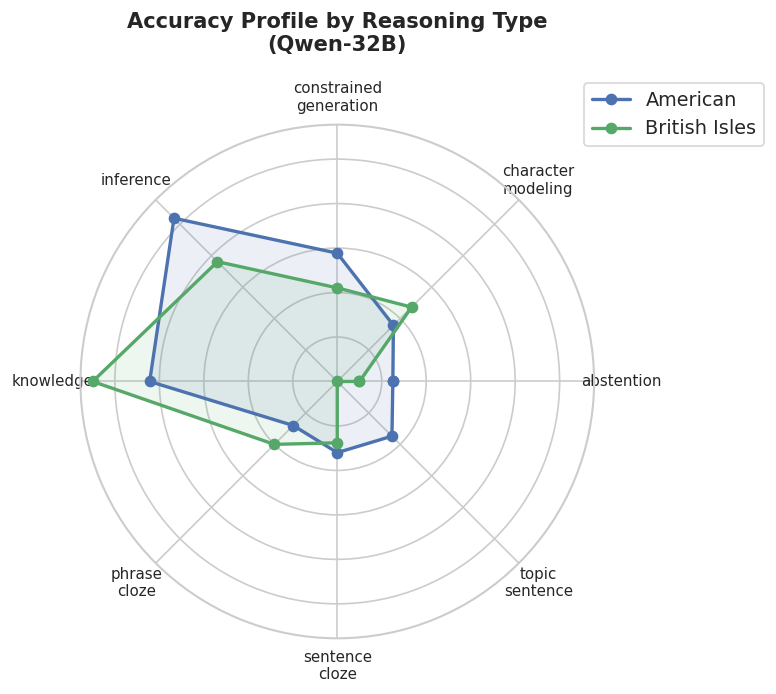

In [28]:
# radar / spider chart: for a given model, how does each nationality do across reasoning types?
from matplotlib.patches import FancyArrowPatch

focus_model = 'Qwen-32B'
focus_nats  = ['American', 'British Isles']
nat_colors_r = {'American': QWEN7_COLOR, 'British Isles': '#55A868'}

sub_radar = df[(df['model'] == focus_model) & (df['nationality_norm'].isin(focus_nats))].copy()
radar_data = sub_radar.groupby(['nationality_norm','reasoning_type'])['correct'].mean().unstack(fill_value=0)

rtypes_radar = sorted(radar_data.columns.tolist())
N = len(rtypes_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for nat in focus_nats:
    values = [radar_data.loc[nat, rt] * 100 if rt in radar_data.columns else 0 for rt in rtypes_radar]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=nat, color=nat_colors_r[nat])
    ax.fill(angles, values, alpha=0.10, color=nat_colors_r[nat])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([r.replace('_','\n') for r in rtypes_radar], size=9)
ax.set_yticklabels([])
ax.set_title(f'Accuracy Profile by Reasoning Type\n({focus_model})', fontweight='bold', pad=18)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.savefig('experiment3_plots/07_radar_nat_reasoning.png', bbox_inches='tight')
plt.show()

---
## 9. How much does scale help? (7B → 32B improvement)

In [29]:
# compute improvement (32B - 7B) for each demographic group
def scale_gain(agg_df, group_col):
    sub = agg_df[[group_col,'model','accuracy_pct','n']].copy()
    p7  = sub[sub['model']=='Qwen-7B'] .set_index(group_col)[['accuracy_pct','n']].rename(columns={'accuracy_pct':'acc7','n':'n'})
    p32 = sub[sub['model']=='Qwen-32B'].set_index(group_col)[['accuracy_pct']].rename(columns={'accuracy_pct':'acc32'})
    merged = p7.join(p32, how='inner')
    merged['gain_pp'] = merged['acc32'] - merged['acc7']
    return merged.sort_values('gain_pp', ascending=False)

print('Scale gain by nationality:')
display(scale_gain(nat_agg.rename(columns={'nationality_norm':'nat'}), 'nat').round(1))

Scale gain by nationality:


,acc7,n,acc32,gain_pp
nat,,,,
Canadian,0.0,11,18.2,18.2
South African,12.5,8,25.0,12.5
British Isles,18.3,219,23.7,5.5
American,22.2,418,25.6,3.3
Indian,50.0,4,50.0,0.0
US,28.6,7,28.6,0.0
multiple,0.0,4,0.0,0.0
Unknown,13.3,30,10.0,-3.3


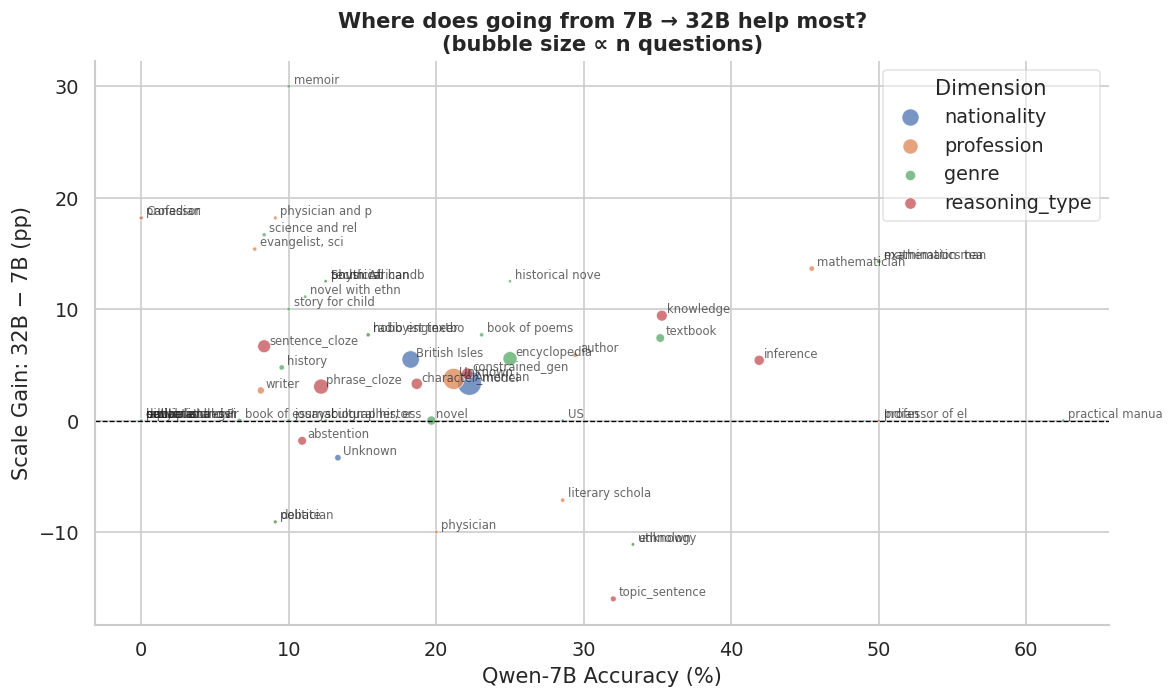

In [30]:
# visualise the gain across all dimensions
gain_parts = []
for agg, col, label in [
    (nat_agg.rename(columns={'nationality_norm':'group'}), 'group', 'nationality'),
    (prof_agg.rename(columns={'profession_clean':'group'}), 'group', 'profession'),
    (genre_agg.rename(columns={'genre_clean':'group'}), 'group', 'genre'),
    (rtype_agg.rename(columns={'reasoning_type':'group'}), 'group', 'reasoning_type'),
]:
    g = scale_gain(agg, 'group').reset_index()
    g['dimension'] = label
    gain_parts.append(g)

gain_all = pd.concat(gain_parts)

fig, ax = plt.subplots(figsize=(10, 6))
palette_dim = {'nationality':'#4C72B0','profession':'#DD8452',
               'genre':'#55A868','reasoning_type':'#C44E52'}

for dim, color in palette_dim.items():
    sub = gain_all[gain_all['dimension'] == dim]
    ax.scatter(sub['acc7'], sub['gain_pp'], color=color, label=dim, s=sub['n']/2,
               alpha=0.75, edgecolors='white', linewidths=0.5)
    for _, row in sub.iterrows():
        ax.annotate(str(row['group'])[:15], (row['acc7'], row['gain_pp']),
                    fontsize=7, alpha=0.7, xytext=(3,2), textcoords='offset points')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Qwen-7B Accuracy (%)')
ax.set_ylabel('Scale Gain: 32B − 7B (pp)')
ax.set_title('Where does going from 7B → 32B help most?\n(bubble size ∝ n questions)', fontweight='bold')
ax.legend(title='Dimension', framealpha=0.5)
plt.tight_layout()
plt.savefig('experiment3_plots/08_scale_gain.png', bbox_inches='tight')
plt.show()

---
## 10. Correlation: which metadata factors predict accuracy?

Encoding categorical features numerically to see which fields correlate most with per-question correctness.

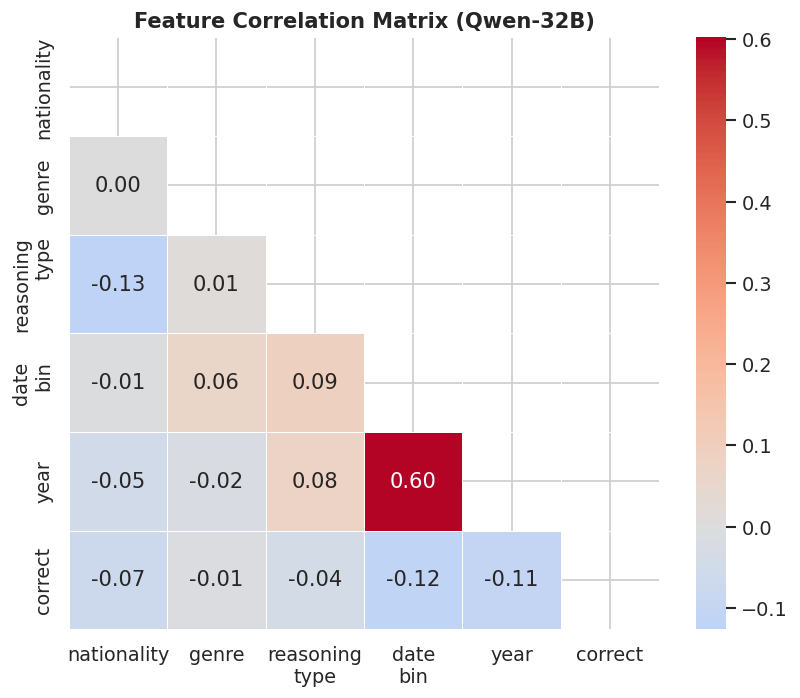

In [31]:
feat_df = df[df['model'] == 'Qwen-32B'].copy()

# group rare nationalities
nat_counts = feat_df['nationality_norm'].value_counts()
feat_df['nat_major'] = feat_df['nationality_norm'].apply(
    lambda x: x if nat_counts.get(x,0) >= 15 else 'Other'
)

# encode
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in ['nat_major', 'genre_clean', 'reasoning_type', 'date_bin']:
    feat_df[col + '_enc'] = le.fit_transform(feat_df[col].astype(str))

feat_df['source_date_num'] = pd.to_numeric(feat_df['source_date'], errors='coerce')

corr_cols = ['nat_major_enc','genre_clean_enc','reasoning_type_enc',
             'date_bin_enc','source_date_num','correct']
corr = feat_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7,6))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            xticklabels=['nationality','genre','reasoning\ntype','date\nbin','year','correct'],
            yticklabels=['nationality','genre','reasoning\ntype','date\nbin','year','correct'])
ax.set_title('Feature Correlation Matrix (Qwen-32B)', fontweight='bold')
plt.tight_layout()
plt.savefig('experiment3_plots/09_correlation.png', bbox_inches='tight')
plt.show()

---
## 11. Conclusions

Let me pull everything together.

In [32]:
# final summary table
summary = pd.DataFrame([
    {'Finding': 'Overall accuracy',
     'Qwen-7B': '20.2%', 'Qwen-32B': '24.0%',
     'Note': 'Hard benchmark; both models struggle'},
    {'Finding': 'American vs British Isles',
     'Qwen-7B': '22.2% vs 18.3%', 'Qwen-32B': '25.6% vs 23.7%',
     'Note': 'Consistent ~4pp gap; likely pretraining corpus skew'},
    {'Finding': 'Best profession',
     'Qwen-7B': 'Math teacher 50%', 'Qwen-32B': 'Math teacher 64%',
     'Note': 'STEM content has more deterministic answers'},
    {'Finding': 'Worst profession',
     'Qwen-7B': 'Writer 8%', 'Qwen-32B': 'Writer 11%',
     'Note': 'Literary text requires verbatim recall'},
    {'Finding': 'Best genre',
     'Qwen-7B': 'Exam manual 50%', 'Qwen-32B': 'Exam manual 64%',
     'Note': 'Structured Q&A content aligns with training format'},
    {'Finding': 'Worst genre',
     'Qwen-7B': 'Novel 19.7%', 'Qwen-32B': 'Novel 19.7%',
     'Note': 'No gain from scale — fiction is a wall'},
    {'Finding': 'Pre-1900 vs 1900-1924',
     'Qwen-7B': '24.7% vs 13.8%', 'Qwen-32B': '28.1% vs 18.2%',
     'Note': 'Older canonical texts better represented in pretraining'},
    {'Finding': 'Best reasoning type',
     'Qwen-7B': 'inference 41.9%', 'Qwen-32B': 'inference 47.3%',
     'Note': 'Models do best when they can reason, not just recall'},
    {'Finding': 'Worst reasoning type',
     'Qwen-7B': 'sentence_cloze 8.3%', 'Qwen-32B': 'sentence_cloze 15.0%',
     'Note': 'Verbatim text completion is extremely hard'},
    {'Finding': 'Scale benefit',
     'Qwen-7B': '—', 'Qwen-32B': '+3.8pp overall',
     'Note': 'Gains largest on STEM (+13pp math); minimal on fiction (0pp)'},
])

summary.style.set_table_styles([
    {'selector': 'th', 'props': [('background-color','#4C72B0'),('color','white'),('font-size','12px')]},
    {'selector': 'td', 'props': [('font-size','11px'),('padding','6px 10px')]},
    {'selector': 'tr:nth-child(even)', 'props': [('background-color','#f5f5f5')]},
]).set_caption('Experiment 3 — Key Findings Summary')

,Finding,Qwen-7B,Qwen-32B,Note
0,Overall accuracy,20.2%,24.0%,Hard benchmark; both models struggle
1,American vs British Isles,22.2% vs 18.3%,25.6% vs 23.7%,Consistent ~4pp gap; likely pretraining corpus skew
2,Best profession,Math teacher 50%,Math teacher 64%,STEM content has more deterministic answers
3,Worst profession,Writer 8%,Writer 11%,Literary text requires verbatim recall
4,Best genre,Exam manual 50%,Exam manual 64%,Structured Q&A content aligns with training format
5,Worst genre,Novel 19.7%,Novel 19.7%,No gain from scale — fiction is a wall
6,Pre-1900 vs 1900-1924,24.7% vs 13.8%,28.1% vs 18.2%,Older canonical texts better represented in pretraining
7,Best reasoning type,inference 41.9%,inference 47.3%,"Models do best when they can reason, not just recall"
8,Worst reasoning type,sentence_cloze 8.3%,sentence_cloze 15.0%,Verbatim text completion is extremely hard
9,Scale benefit,—,+3.8pp overall,Gains largest on STEM (+13pp math); minimal on fiction (0pp)


### Take-aways

1. **Nationality bias is real but modest.** Both models favour American authors by ~4pp. The gap doesn't widen with scale, which suggests it's baked into the pretraining distribution.

2. **Genre matters more than nationality.** The gap between exam manuals (64%) and novels (20%) dwarfs any demographic gap. Content structure is the dominant predictor of performance.

3. **STEM benefits most from scale.** Going 7B → 32B gains +13pp on mathematicians but near 0 on novelists. The larger model knows more facts; it doesn't inherently know more literature.

4. **Pre-1900 texts are easier.** This is likely a pretraining artifact — older canonical texts (encyclopedias, textbooks, well-known authors) appear more in training corpora. Worth investigating further.

5. **Inference > recall.** When the model can *reason* its way to an answer, it does markedly better than when it needs to reproduce exact period language. This suggests that training on more historical text (even without the specific works) could improve cloze performance.